# Del Excel al Modelo: pricing con un GLM
### Demo — Herramientas de análisis de datos para actuarios

**Objetivo de esta demo:** tomar un CSV crudo, entenderlo, y construir un modelo de
pricing que sea **explicable, auditable y defendible** — con poco SQL y poco Python.

No vamos a programar mucho. Vamos a **pensar como actuarios** y dejar que la herramienta
haga el trabajo pesado.

**El problema:** una aseguradora de salud quiere ponerle precio a sus pólizas.
¿Cuánto cobrarle a cada asegurado según su riesgo?

> **Pregunta para abrir:** tenemos dos personas.
> - **Ana:** 25 años, no fuma, peso saludable, sin hijos.
> - **Carlos:** 55 años, fuma, sobrepeso, dos hijos.
>
> ¿Les cobrarías lo mismo? ¿Cuánto a cada uno? Al final de la demo, el modelo va a responder.

## 0. Setup del entorno (serverless)

En **serverless compute** el entorno es efímero y MLflow no siempre viene preinstalado
(o trae una versión que no calza con este código). Por eso fijamos las dependencias
explícitamente. **Corré esta celda PRIMERO** — reinicia el kernel de Python.

> Si usás un cluster ML clásico, esta celda no hace falta, pero no molesta.

In [0]:
# Dependencias fijadas para que la demo corra igual en cualquier sesion serverless.
# MLflow 2.x: mantiene la API de log_model(artifact_path=...) y UC que usa este notebook.
%pip install -q "mlflow>=2.20,<3" "statsmodels>=0.14" scikit-learn

# restartPython aplica los paquetes nuevos al kernel. Tras esto, re-ejecuta desde la seccion 1.
dbutils.library.restartPython()

## 1. Cargar el dato crudo

Esto es lo que normalmente vive en un Excel que alguien te pasó por mail.
Acá lo cargamos como una tabla. En Databricks real, esto sería una tabla gobernada
en Unity Catalog; para la demo lo leemos directo del CSV.

In [0]:
import pandas as pd
import numpy as np
import mlflow

# Tabla GOBERNADA de Unity Catalog (no un archivo suelto): dueño, permisos, historial.
TABLA_UC = "cpce.actuarial_demo.insurance"

# spark.table() lee la tabla via Spark -> UC registra el LINEAGE notebook -> tabla
# (este notebook aparece como 'consumer' de la tabla en Catalog Explorer).
sdf = spark.table(TABLA_UC)                             # Spark DataFrame
df  = sdf.toPandas()                                    # pandas, para modelar con statsmodels

# Ademas envolvemos ese mismo Spark DF como *MLflow dataset*. Esto NO vuelve a leer la
# tabla: solo guarda la referencia (catalogo.schema.tabla) para el log_input del modelo,
# que es lo que conecta el LINEAGE tabla -> modelo mas adelante.
dataset = mlflow.data.from_spark(sdf, table_name=TABLA_UC)

# (Para correr LOCAL fuera de Databricks, comentá las líneas de arriba y usá:)
# df = pd.read_csv("insurance.csv"); dataset = None

print(f"Filas: {df.shape[0]}  |  Columnas: {df.shape[1]}")
df.head(10)

Filas: 1338  |  Columnas: 7


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
5,31,female,25.740,0,no,southeast,3756.62160
6,46,female,33.440,1,no,southeast,8240.58960
7,37,female,27.740,3,no,northwest,7281.50560
8,37,male,29.830,2,no,northeast,6406.41070
9,60,female,25.840,0,no,northwest,28923.13692


### ¿Qué significa cada columna?

| Columna | Qué es | Tipo |
|---|---|---|
| `age` | Edad del asegurado | Numérica |
| `sex` | Sexo | Categórica |
| `bmi` | Índice de masa corporal | Numérica |
| `children` | Cantidad de hijos a cargo | Numérica |
| `smoker` | ¿Fuma? | Categórica (yes/no) |
| `region` | Región del país | Categórica |
| **`charges`** | **Gasto médico anual ($)** — *esto es lo que queremos predecir* | Numérica |

`charges` es nuestra **variable objetivo (target)**: el costo que la aseguradora termina
pagando. Si lo podemos predecir, podemos ponerle precio a la póliza.

## 2. Data profiling: ¿podemos confiar en este dato?

Antes de modelar, **el actuario tiene que mirar el dato**. Un modelo sobre dato sucio
es una decisión sucia. Tres preguntas básicas:
1. ¿Hay valores faltantes?
2. ¿Los rangos tienen sentido?
3. ¿Hay cosas raras (outliers, categorías inesperadas)?

### Profiling automático de Databricks (una línea, cero esfuerzo)

Databricks genera un perfil completo del dato — histogramas, nulos, estadísticas,
valores únicos — con un solo comando. Esto es lo que un analista mira ANTES de modelar.

In [0]:
# Profiling interactivo: tras ejecutar, abrí la pestaña Data Profile en los resultados.
display(sdf)

age,sex,bmi,children,smoker,region,charges
19,female,27.9,0,yes,southwest,16884.924
18,male,33.77,1,no,southeast,1725.5523
28,male,33.0,3,no,southeast,4449.462
33,male,22.705,0,no,northwest,21984.47061
32,male,28.88,0,no,northwest,3866.8552
31,female,25.74,0,no,southeast,3756.6216
46,female,33.44,1,no,southeast,8240.5896
37,female,27.74,3,no,northwest,7281.5056
37,male,29.83,2,no,northeast,6406.4107
60,female,25.84,0,no,northwest,28923.13692


### Y ahora a mano: entender qué estamos mirando

El botón es cómodo, pero el actuario tiene que SABER leerlo. Repasemos las 3 preguntas.

In [0]:
# 1) Valores faltantes — clave para auditoría
print("=== Valores faltantes por columna ===")
print(df.isnull().sum().to_string())
print("\n>>> Cero nulos: el dato está completo. Buena señal.")

=== Valores faltantes por columna ===
age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0

>>> Cero nulos: el dato está completo. Buena señal.


In [0]:
# 2) Resumen estadístico de las numéricas — ¿los rangos tienen sentido?
df.describe().round(2)

,age,bmi,children,charges
count,1338.00,1338.00,1338.00,1338.00
mean,39.21,30.66,1.09,13270.42
std,14.05,6.10,1.21,12110.01
min,18.00,15.96,0.00,1121.87
25%,27.00,26.30,0.00,4740.29
50%,39.00,30.40,1.00,9382.03
75%,51.00,34.69,2.00,16639.91
max,64.00,53.13,5.00,63770.43


**Lectura actuarial del resumen:**
- `age`: de 18 a 64 → población adulta, coherente.
- `bmi`: media ~30 → la muestra tiende al sobrepeso (BMI > 25). Dato relevante para salud.
- `charges`: media ~13.270 pero el máximo es ~63.770. **La media está lejos del máximo:
  hay una cola larga a la derecha.** Esto va a ser CLAVE para elegir el modelo.

In [0]:
# 3) Categóricas — ¿qué valores aparecen y en qué proporción?
for col in ["sex", "smoker", "region"]:
    print(f"=== {col} ===")
    print(df[col].value_counts().to_string())
    print()

=== sex ===
male      676
female    662

=== smoker ===
no     1064
yes     274

=== region ===
southeast    364
southwest    325
northwest    325
northeast    324



## 3. EDA: dejar que el dato hable

Antes de cualquier modelo, una mirada visual. La pregunta del actuario:
**¿qué variables parecen mover el costo?**

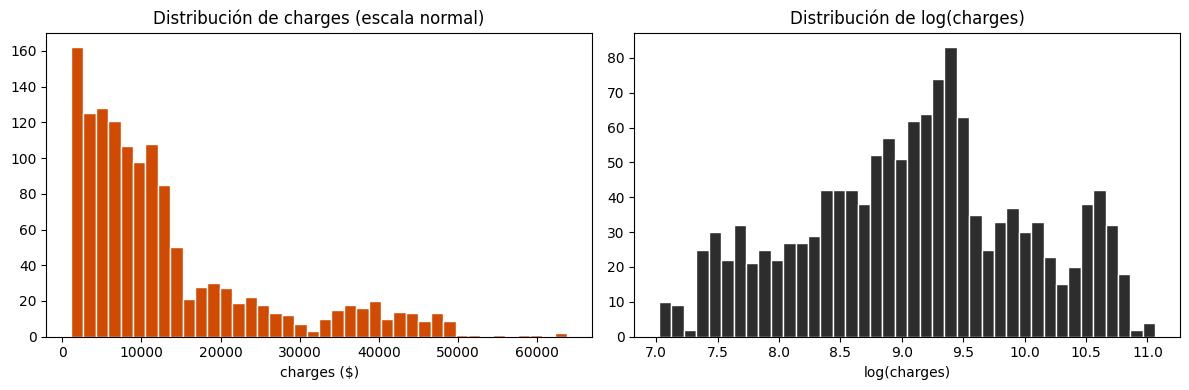

Asimetría (skew) de charges: 1.52
>>> skew > 0 = cola a la derecha: es una PISTA de que el target no es una campana.
>>> Lo de fondo: charges es estrictamente positivo. La lineal comun no lo respeta
>>> (predice negativos); por eso vamos a un GLM para variable positiva.


In [0]:
import matplotlib.pyplot as plt

# La distribución del target: ¿es una campana o tiene cola?
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(df["charges"], bins=40, color="#D04A02", edgecolor="white")
axes[0].set_title("Distribución de charges (escala normal)")
axes[0].set_xlabel("charges ($)")

axes[1].hist(np.log(df["charges"]), bins=40, color="#2D2D2D", edgecolor="white")
axes[1].set_title("Distribución de log(charges)")
axes[1].set_xlabel("log(charges)")
plt.tight_layout()
plt.show()

print(f"Asimetría (skew) de charges: {df['charges'].skew():.2f}")
print(">>> skew > 0 = cola a la derecha: es una PISTA de que el target no es una campana.")
print(">>> Lo de fondo: charges es estrictamente positivo. La lineal comun no lo respeta")
print(">>> (predice negativos); por eso vamos a un GLM para variable positiva.")

**Este gráfico es media demo.** A la izquierda, `charges` tiene una cola larga: muchos
asegurados baratos, pocos carísimos. A la derecha, al aplicar `log`, se "normaliza".

> **Por qué importa:** la regresión lineal clásica asume una campana simétrica y puede
> predecir **valores negativos**. Una prima negativa es absurda (la aseguradora te pagaría
> a vos). Necesitamos un modelo cuyo target sea **estrictamente positivo** — y esa es la
> razón de fondo para el **GLM Gamma con link logarítmico** (la cola que ves acá es la
> consecuencia visible de modelar un monto positivo, no el criterio en sí).

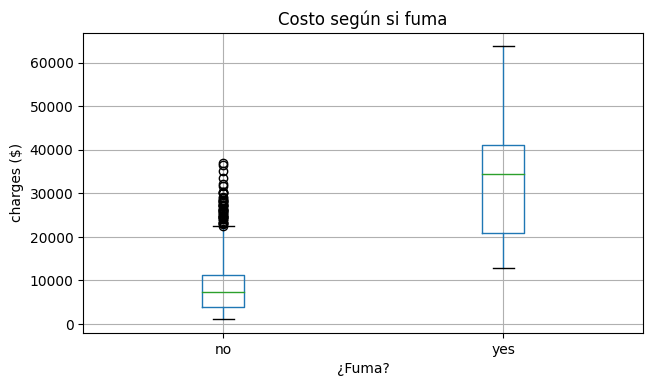

smoker
no      8434.0
yes    32050.0

>>> Los fumadores cuestan en promedio ~4x más. El dato confirma la intuición.


In [0]:
# El efecto que TODOS intuyen: fumar
fig, ax = plt.subplots(figsize=(7, 4))
df.boxplot(column="charges", by="smoker", ax=ax)
ax.set_title("Costo según si fuma")
ax.set_xlabel("¿Fuma?")
ax.set_ylabel("charges ($)")
plt.suptitle("")
plt.show()

print(df.groupby("smoker")["charges"].mean().round(0).to_string())
print("\n>>> Los fumadores cuestan en promedio ~4x más. El dato confirma la intuición.")

## 4. El GLM: el modelo como motor técnico

Recordemos los **tres ingredientes** del GLM:
1. **Distribución (familia):** ¿cómo se comporta el target? → elegimos **Gamma**.
2. **Función de enlace (link):** ¿cómo conectamos las variables con el target? → usamos
   **link logarítmico**, que hace que los efectos sean **multiplicativos**.
3. **Predictor lineal:** la combinación de variables de riesgo (edad, fumar, BMI, etc.).

> **¿Por qué Gamma? (importante, no es "porque tiene cola")** Dos razones de fondo:
> 1. **El soporte: `charges` es estrictamente positivo.** Gamma solo existe en (0, +∞);
>    un gasto médico no puede ser negativo. *Esta es la razón principal.*
> 2. **La relación media-varianza:** en Gamma la varianza crece con la media — los riesgos
>    caros también son más volátiles, justo lo que pasa en seguros.
>
> La cola a la derecha (skew 1.52) es una **pista visual** de esto, no el criterio en sí.
> *(La **log-normal** sería una alternativa válida: también positiva y con cola. Usamos
> Gamma porque es el estándar de pricing y modela directo la media en escala original.)*

> **Por qué link log = multiplicativo:** si el coeficiente de `smoker` es 1.5, entonces
> `exp(1.5) ≈ 4.5`. Eso se lee directo: **"fumar multiplica la prima por 4.5"**.
> Esto es EXACTAMENTE lo que un actuario lleva a una tabla de tarifas: una relatividad.

In [0]:
import statsmodels.formula.api as smf
import statsmodels.api as sm

# La fórmula declara el modelo en lenguaje casi natural.
# C(...) marca variables categóricas (statsmodels crea las dummies solo).
formula = "charges ~ age + bmi + children + C(sex) + C(smoker) + C(region)"

modelo = smf.glm(
    formula=formula,
    data=df,
    family=sm.families.Gamma(link=sm.families.links.Log())
).fit()

print(">>> Modelo entrenado. Una línea de código. El resto es interpretación.")

>>> Modelo entrenado. Una línea de código. El resto es interpretación.


## 5. Explicabilidad: por qué los stakeholders prefieren el GLM

Acá está el corazón de la charla. El GLM no es una caja negra: **cada variable tiene un
número que podés explicar, defender ante un regulador, y justificar ante el negocio.**

In [0]:
# Tabla de relatividades: el output que un actuario lleva a una reunión
resultados = pd.DataFrame({
    "coeficiente": modelo.params,
    "relatividad": np.exp(modelo.params),   # exp(coef) = factor multiplicativo
    "p_value": modelo.pvalues,
}).round(4)
resultados["significativa?"] = np.where(resultados["p_value"] < 0.05, "Sí", "NO")
resultados

,coeficiente,relatividad,p_value,significativa?
Intercept,7.3863,1613.7842,0.0000,Sí
C(sex)[T.male],-0.0571,0.9445,0.1283,NO
C(smoker)[T.yes],1.5003,4.4832,0.0000,Sí
C(region)[T.northwest],-0.0579,0.9438,0.2810,NO
C(region)[T.southeast],-0.1416,0.8679,0.0087,Sí
C(region)[T.southwest],-0.1455,0.8646,0.0069,Sí
age,0.0286,1.0291,0.0000,Sí
bmi,0.0141,1.0142,0.0000,Sí
children,0.0842,1.0878,0.0000,Sí


**Cómo se lee esta tabla (esto es lo que defendés ante un stakeholder):**

| Variable | Relatividad | Traducción al negocio |
|---|---|---|
| `smoker=yes` | **~4.48** | Fumar **multiplica la prima por 4.5**. Efecto enorme y nítido. |
| `age` | ~1.029 | Cada año de edad suma **~2.9%** a la prima. |
| `bmi` | ~1.014 | Cada punto de BMI suma **~1.4%**. |
| `children` | ~1.088 | Cada hijo a cargo suma **~8.8%**. |
| `sex=male` | ~0.94 | **p-value > 0.05 → NO es significativa.** |
| `region` (sur) | ~0.86 | El sur paga ~14% menos que el noreste (base). |

> **El regalo de honestidad:** el modelo nos dice que `sex`, una vez controlado todo lo
> demás, **no aporta**. Un buen modelo te dice qué importa Y qué no. Eso es defendible —
> y además, en muchas jurisdicciones tarifar por sexo está prohibido. El modelo coincide
> con la regulación.

## 5.5 Un paso más: feature engineering

El modelo de arriba usa las 7 columnas **tal cual vinieron** — y ya es explicable y
defendible. Pero un actuario rara vez se queda en el dato crudo: lo **transforma** para
capturar mejor el riesgo. Eso es *feature engineering*, y es donde entra el conocimiento
del negocio.

Veamos un ejemplo concreto que vive escondido en este dataset: la **interacción entre
fumar y el BMI**. Y vamos a usarlo para una lección que vale oro: **que una variable sea
estadísticamente significativa NO garantiza que mejore las predicciones.**

In [0]:
# ¿El efecto del BMI es el mismo para fumadores y no fumadores?
tmp = df.copy()
tmp["obeso"] = np.where(tmp["bmi"] >= 30, "obeso (BMI>=30)", "no obeso (BMI<30)")

tabla = tmp.groupby(["smoker", "obeso"])["charges"].mean().round(0).unstack()
print("Gasto medico promedio segun fumar y obesidad:")
print(tabla.to_string())

# Factor multiplicativo del BMI DENTRO de cada grupo de fumador
f_no  = tabla.loc["no",  "obeso (BMI>=30)"] / tabla.loc["no",  "no obeso (BMI<30)"]
f_yes = tabla.loc["yes", "obeso (BMI>=30)"] / tabla.loc["yes", "no obeso (BMI<30)"]
print(f"\nFactor obesidad en NO fumadores: x{f_no:.2f}  (casi no encarece)")
print(f"Factor obesidad en fumadores   : x{f_yes:.2f}  (casi DUPLICA)")
print("\n>>> El BMI pesa muchisimo mas en fumadores. El efecto de una variable")
print(">>> DEPENDE del nivel de otra: eso es una interaccion.")

Gasto medico promedio segun fumar y obesidad:
obeso   no obeso (BMI<30)  obeso (BMI>=30)
smoker                                    
no                 7977.0           8843.0
yes               21363.0          41558.0

Factor obesidad en NO fumadores: x1.11  (casi no encarece)
Factor obesidad en fumadores   : x1.95  (casi DUPLICA)

>>> El BMI pesa muchisimo mas en fumadores. El efecto de una variable
>>> DEPENDE del nivel de otra: eso es una interaccion.


### "¿Pero el link log no hace ya los efectos multiplicativos?" — Sí, y aún así no alcanza

Pregunta muy buena (y muy común). Son **dos cosas distintas**:

| | Qué decide | De dónde sale |
|---|---|---|
| **Link log** | La *forma* de combinar factores: multiplicativa en vez de aditiva | la función de enlace |
| **Interacción** | Si el *tamaño* de un factor cambia según otra variable | el término `smoker:bmi` |

Con link log y `smoker + bmi` (sin interacción), el modelo asume:

$$\text{charges} = \text{base} \times f_{\text{fuma}} \times f_{\text{bmi}}$$

y ese $f_{\text{bmi}}$ es **el mismo** fumes o no. Pero el cuadro de arriba mostró que la
obesidad casi no pega en no fumadores y casi duplica en fumadores. No son iguales → el
link log *solo* no lo captura. Necesitás el término de **interacción** para que el modelo
aprenda **un factor de BMI para fumadores y otro para no fumadores**.

> **Regla mental:** el link decide *cómo* se multiplican los factores; la interacción
> decide *si un factor cambia de tamaño* según otra variable. Son ortogonales.

Metámosla en el GLM y veamos qué dice.

In [0]:
# Mismo GLM, pero agregando la interaccion smoker:bmi a la formula.
# C(smoker):bmi NO necesita una columna nueva: statsmodels arma el termino solo.
formula_inter = formula + " + C(smoker):bmi"

modelo_inter = smf.glm(
    formula=formula_inter,
    data=df,
    family=sm.families.Gamma(link=sm.families.links.Log())
).fit()

cf = pd.DataFrame({
    "relatividad": np.exp(modelo_inter.params),
    "p_value": modelo_inter.pvalues,
}).round(4)
cf["significativa?"] = np.where(cf["p_value"] < 0.05, "Si", "NO")

print("Terminos de BMI y fumar (mira la interaccion):")
print(cf[cf.index.str.contains("bmi", case=False)].to_string())
print()
print(">>> bmi base (no fumadores): ~x1.00, NO significativo -> el BMI casi no importa...")
print(">>> C(smoker)[T.yes]:bmi   : ~x1.05, p=0.0000 -> ...salvo si fumas: +5% por punto de BMI.")
print(">>> Ese termino es la interaccion, y es ALTAMENTE significativa (p=0.000).")
print(">>> Pero atencion: significativa NO es lo mismo que util para predecir. Veamos...")

Terminos de BMI y fumar (mira la interaccion):
                      relatividad  p_value significativa?
bmi                        1.0039   0.2766             NO
C(smoker)[T.yes]:bmi       1.0481   0.0000             Si

>>> bmi base (no fumadores): ~x1.00, NO significativo -> el BMI casi no importa...
>>> C(smoker)[T.yes]:bmi   : ~x1.05, p=0.0000 -> ...salvo si fumas: +5% por punto de BMI.
>>> Ese termino es la interaccion. Un GLM sin el no la ve.


In [0]:
# La prueba honesta: la interaccion mejora la PREDICCION en datos nuevos?
# Comparamos R2 en test con y sin el termino de interaccion.
from sklearn.model_selection import train_test_split

tr_fe, te_fe = train_test_split(df, test_size=0.2, random_state=42)

def _r2(y, yh):
    return 1 - ((y - yh)**2).sum() / ((y - y.mean())**2).sum()

fam = sm.families.Gamma(link=sm.families.links.Log())
m_sin = smf.glm(formula=formula,                      data=tr_fe, family=fam).fit()
m_con = smf.glm(formula=formula + " + C(smoker):bmi", data=tr_fe, family=fam).fit()

r2_sin = _r2(te_fe["charges"], m_sin.predict(te_fe))
r2_con = _r2(te_fe["charges"], m_con.predict(te_fe))

print("=== R2 en test (datos NUNCA vistos) ===")
print(f"  SIN interaccion: {r2_sin:.3f}")
print(f"  CON interaccion: {r2_con:.3f}")
print()
print(">>> La interaccion es significativa (p=0.000) pero NO mejora el R2 en test.")
print(">>> Tiene sentido medico, pero en ESTE dataset los datos no la respaldan para predecir.")
print(">>> Leccion: significancia estadistica != poder predictivo. Siempre validar en test.")

### La lección: significancia ≠ poder predictivo

Acabamos de ver algo que confunde a muchos analistas:

| Pregunta | La responde... | Respuesta acá |
|---|---|---|
| ¿El efecto **existe** en mis datos? | el **p-value** | Sí, rotundo (p=0.000) |
| ¿Me ayuda a **predecir** casos nuevos? | el **R² en test** | No, en este dataset |

¿Cómo conviven? La interacción captura un patrón **real** (fumar + obeso es peor que la
suma), pero la señal de fumar **ya está casi toda** en el término `smoker` solo. El extra
que aporta la interacción es chico, y sobre el conjunto de test no se traduce en mejor
predicción — incluso agrega un poco de varianza que penaliza.

> **La trampa del analista junior:** ver `p < 0.05` y meter la variable sin pensar. Un
> actuario maduro sabe que la significancia es necesaria pero **no suficiente**: la prueba
> final siempre es ¿predice mejor en datos que no vio? Esto conecta directo con el
> **sobreajuste** (sección 10): agregar complejidad que el dato no respalda es justo cómo
> empieza un modelo a romperse.

*(Por eso el modelo que llevamos a producción sigue siendo el simple. La interacción
queda documentada como hipótesis razonable que este dataset no logró confirmar.)*

### ¿Por qué Gamma+log y no una regresión lineal común?

Comparemos el GLM contra un modelo lineal ingenuo (OLS). No es teoría: miremos qué pasa.

In [0]:
# Modelo lineal ingenuo, para contraste
ols = smf.ols(formula, data=df).fit()

predicciones_ols = ols.fittedvalues
primas_negativas = (predicciones_ols < 0).sum()

print(f"El modelo LINEAL ingenuo predice {primas_negativas} primas NEGATIVAS.")
print(">>> Una prima negativa es imposible: la aseguradora le pagaría al asegurado.")
print(">>> El GLM Gamma con link log GARANTIZA predicciones positivas por diseño.")
print()
print("Ejemplos de primas negativas del modelo lineal:")
print(predicciones_ols[predicciones_ols < 0].head().round(0).to_string())

El modelo LINEAL ingenuo predice 20 primas NEGATIVAS.
>>> Una prima negativa es imposible: la aseguradora le pagaría al asegurado.
>>> El GLM Gamma con link log GARANTIZA predicciones positivas por diseño.

Ejemplos de primas negativas del modelo lineal:
28     -143.0
35     -615.0
172   -2033.0
232   -1981.0
248    -585.0


> **Nota de honestidad intelectual:** en error absoluto puro, el modelo lineal puede
> parecer "competitivo". Pero produce resultados imposibles (primas negativas) y asume
> una distribución que el dato NO tiene. Elegir el modelo no es buscar la métrica más
> alta: es elegir la herramienta **correcta para el problema**. El GLM es correcto Y
> explicable. Por eso lo prefieren los stakeholders.

## 6. Scoring: cerrar el círculo con Ana y Carlos

Volvamos a la pregunta del inicio. El modelo ya entrenado le pone precio a cada uno.

In [0]:
clientes = pd.DataFrame([
    {"age": 25, "sex": "female", "bmi": 23, "children": 0, "smoker": "no",  "region": "southeast"},  # Ana
    {"age": 55, "sex": "male",   "bmi": 31, "children": 2, "smoker": "yes", "region": "southeast"},  # Carlos
], index=["Ana", "Carlos"])

clientes["prima_estimada ($)"] = modelo.predict(clientes).round(0)
clientes

,age,sex,bmi,children,smoker,region,prima_estimada ($)
Ana,25,female,23,0,no,southeast,3966.0
Carlos,55,male,31,2,yes,southeast,52534.0


> **El cierre:** Ana paga una fracción de lo de Carlos — y podemos explicar EXACTAMENTE
> por qué: la edad, el BMI, los hijos y, sobre todo, **fumar (×4.5)**. No es un número
> mágico de una caja negra: es una decisión trazable, auditable y defendible.
>
> Eso es lo que un actuario lleva a una reunión. Eso es lo que un regulador aprueba.

## 7. ¿El modelo es bueno? Validación honesta

Un modelo que solo se mide sobre los datos con los que aprendió **siempre se ve bien**.
La prueba de verdad: ¿funciona con datos que NUNCA vio? Para eso partimos los datos en
**entrenamiento (80%)** y **prueba (20%)**, entrenamos con el primero y medimos en el segundo.

In [0]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Partimos: 80% para entrenar, 20% para probar (datos NUNCA vistos por el modelo)
train, test = train_test_split(df, test_size=0.2, random_state=42)

modelo_val = smf.glm(
    formula=formula, data=train,
    family=sm.families.Gamma(link=sm.families.links.Log())
).fit()

# Predecimos sobre el conjunto de PRUEBA
pred_test = modelo_val.predict(test)

mae = mean_absolute_error(test["charges"], pred_test)
rmse = np.sqrt(mean_squared_error(test["charges"], pred_test))
ss_res = ((test["charges"] - pred_test) ** 2).sum()
ss_tot = ((test["charges"] - test["charges"].mean()) ** 2).sum()
r2_test = 1 - ss_res / ss_tot

print("=== Desempeño sobre datos NUNCA vistos (test) ===")
print(f"  R² (test):  {r2_test:.3f}   → explica el {r2_test*100:.0f}% de la variación del costo")
print(f"  MAE (test): ${mae:,.0f}   → error promedio en dólares")
print(f"  RMSE (test):${rmse:,.0f}")
print("\n>>> El modelo generaliza: rinde parecido en datos nuevos. No está sobreajustado.")

=== Desempeño sobre datos NUNCA vistos (test) ===
  R² (test):  0.656   → explica el 66% de la variación del costo
  MAE (test): $4,155   → error promedio en dólares
  RMSE (test):$7,307

>>> El modelo generaliza: rinde parecido en datos nuevos. No está sobreajustado.


## 8. Visualizar para defender

Una tabla de coeficientes convence a un técnico. Un gráfico convence a TODOS.
Estas dos imágenes son las que llevás a una reunión de negocio.

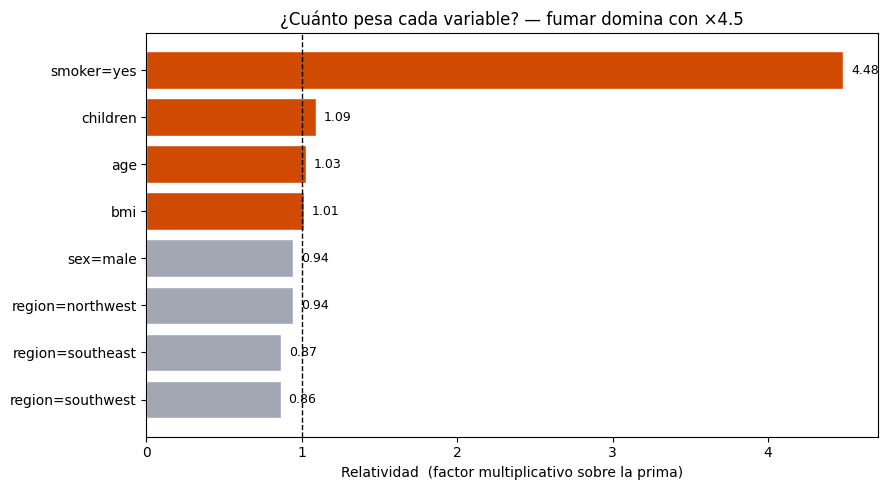

>>> La línea punteada en 1.0 = 'sin efecto'. A la derecha encarece, a la izquierda abarata.
>>> Fumar (×4.5) se despega de todo. El resto son ajustes finos.


In [0]:
import matplotlib.pyplot as plt

# --- Gráfico 1: relatividades (el factor multiplicativo de cada variable) ---
rel = np.exp(modelo.params).drop("Intercept").sort_values()
nombres = [n.replace("C(", "").replace(")", "").replace("[T.", "=").replace("]", "")
           for n in rel.index]

fig, ax = plt.subplots(figsize=(9, 5))
colores = ["#D04A02" if v > 1 else "#A1A8B3" for v in rel.values]
ax.barh(nombres, rel.values, color=colores, edgecolor="white")
ax.axvline(1.0, color="black", linestyle="--", linewidth=1)  # 1.0 = sin efecto
ax.set_xlabel("Relatividad  (factor multiplicativo sobre la prima)")
ax.set_title("¿Cuánto pesa cada variable? — fumar domina con ×4.5")
for i, v in enumerate(rel.values):
    ax.text(v + 0.05, i, f"{v:.2f}", va="center", fontsize=9)
plt.tight_layout()
plt.show()

print(">>> La línea punteada en 1.0 = 'sin efecto'. A la derecha encarece, a la izquierda abarata.")
print(">>> Fumar (×4.5) se despega de todo. El resto son ajustes finos.")

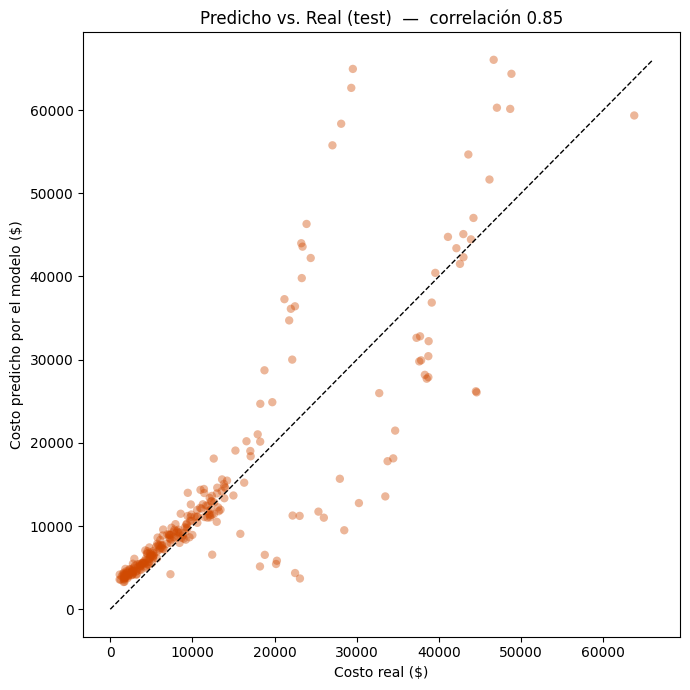

>>> Cuanto más cerca de la diagonal, mejor predice. La nube sigue la línea: el modelo funciona.


In [0]:
# --- Gráfico 2: predicho vs observado (¿le pega el modelo?) ---
fig, ax = plt.subplots(figsize=(7, 7))
ax.scatter(test["charges"], pred_test, alpha=0.4, color="#D04A02", edgecolor="none")
lims = [0, max(test["charges"].max(), pred_test.max())]
ax.plot(lims, lims, "k--", linewidth=1)  # diagonal perfecta
ax.set_xlabel("Costo real ($)")
ax.set_ylabel("Costo predicho por el modelo ($)")
ax.set_title(f"Predicho vs. Real (test)  —  correlación {np.corrcoef(test['charges'], pred_test)[0,1]:.2f}")
plt.tight_layout()
plt.show()

print(">>> Cuanto más cerca de la diagonal, mejor predice. La nube sigue la línea: el modelo funciona.")

## 9. El entregable final: una tabla de tarifas

Todo este trabajo termina en UNA cosa que el negocio usa: una **tabla de tarifas** con
las relatividades. Esto es lo que se carga en el sistema de la aseguradora.

In [0]:
# Tabla de tarifas como HTML lindo (esto es lo que "entrega" el actuario)
factores = {
    "Fumar (sí)": np.exp(modelo.params["C(smoker)[T.yes]"]),
    "Cada año de edad": np.exp(modelo.params["age"]),
    "Cada punto de BMI": np.exp(modelo.params["bmi"]),
    "Cada hijo a cargo": np.exp(modelo.params["children"]),
}
filas = "".join(
    f"<tr><td style='padding:8px 16px;border-bottom:1px solid #eee'>{k}</td>"
    f"<td style='padding:8px 16px;border-bottom:1px solid #eee;text-align:right;"
    f"font-weight:bold;color:#D04A02'>× {v:.3f}</td></tr>"
    for k, v in factores.items()
)
html = f"""
<div style='font-family:Arial,sans-serif;max-width:520px;border:1px solid #ddd;border-radius:8px;overflow:hidden'>
  <div style='background:#D04A02;color:white;padding:14px 16px;font-size:18px;font-weight:bold'>
    Tabla de tarifas — relatividades del modelo
  </div>
  <table style='width:100%;border-collapse:collapse;font-size:15px'>
    <tr style='background:#f7f7f7'>
      <th style='padding:8px 16px;text-align:left'>Factor de riesgo</th>
      <th style='padding:8px 16px;text-align:right'>Relatividad</th>
    </tr>
    {filas}
  </table>
  <div style='padding:12px 16px;font-size:12px;color:#666;background:#fafafa'>
    Prima estimada = prima base × producto de los factores aplicables.<br>
    Modelo GLM Gamma (link log) — cada factor es defendible y auditable.
  </div>
</div>
"""
displayHTML(html)

Factor de riesgo,Relatividad
Fumar (sí),× 4.483
Cada año de edad,× 1.029
Cada punto de BMI,× 1.014
Cada hijo a cargo,× 1.088


## 10. Errores comunes

Hasta acá mostramos el caso lindo. En la vida real, los modelos se rompen por dos razones
recurrentes — y un actuario tiene que reconocerlas a tiempo:

1. **Sobreajuste (overfitting):** el modelo "memoriza" la muestra y falla con datos nuevos.
2. **Dato sucio en la entrada:** nulos, valores imposibles, categorías inventadas — el
   GLM no protesta, simplemente entrega coeficientes que parecen razonables pero están sesgados.

Vamos a reproducir ambos males a propósito, y a usar los mismos clientes — **Ana y Carlos** —
para mostrar **cómo cambia la prima** cuando el modelo está roto. Esto es lo que un
stakeholder o un regulador te van a preguntar: *"¿cómo sabés que tu modelo no falla así?"*

### 10.1 Pecado #1 — sobreajuste (overfitting)

El modelo "estrella" arriba se ve bien porque hicimos las cosas con cuidado: train/test
separados, fórmula simple, muestra completa. ¿Qué pasa si nos descuidamos?

**La receta para sobreajustar:**
1. Entrenar con MUY POCAS filas.
2. Meterle al modelo MUCHAS variables o interacciones (más parámetros que datos).
3. NO mirar las métricas en test.

> **Por qué pasa:** con pocos datos y muchas variables, el modelo se "memoriza" la
> muestra en lugar de aprender el patrón. Brilla en entrenamiento, fracasa en producción.

In [0]:
# Receta para sobreajustar: muy pocos datos + demasiados parámetros
# 1) Nos quedamos con apenas 50 filas para entrenar (las 1.288 restantes son test)
train_chico, test_grande = train_test_split(df, train_size=100, random_state=42)

# 2) Sobreparametrizamos: agregamos un montón de interacciones
#    Cada ":" multiplica variables → muchos coeficientes nuevos.
formula_ofit = (
    "charges ~ age + bmi + children + C(sex) + C(smoker) + C(region) "
    "+ age:bmi + age:children + bmi:children "
    "+ C(smoker):age + C(smoker):bmi + C(region):age"
)

print(f"Filas de entrenamiento: {len(train_chico)}  (¡muy pocas!)")
print(f"Filas de test:          {len(test_grande)}")
print(f"Cantidad de términos en la fórmula: ~14 (más interacciones)")
print(">>> Pocos datos + muchos parámetros = receta perfecta para overfitting.")

Filas de entrenamiento: 100  (¡muy pocas!)
Filas de test:          1238
Cantidad de términos en la fórmula: ~14 (más interacciones)
>>> Pocos datos + muchos parámetros = receta perfecta para overfitting.


In [0]:
# Reentrenamos sobre la muestra pequeña con la fórmula sobreparametrizada
modelo_ofit = smf.glm(
    formula=formula_ofit,
    data=train_chico,
    family=sm.families.Gamma(link=sm.families.links.Log())
).fit()

# Métricas en TRAIN (lo que vio) vs TEST (lo que NO vio)
pred_train_ofit = modelo_ofit.predict(train_chico)
pred_test_ofit  = modelo_ofit.predict(test_grande)

def r2(y, yhat):
    ss_res = ((y - yhat) ** 2).sum()
    ss_tot = ((y - y.mean()) ** 2).sum()
    return 1 - ss_res / ss_tot

r2_train = r2(train_chico["charges"], pred_train_ofit)
r2_test  = r2(test_grande["charges"], pred_test_ofit)
mae_train = mean_absolute_error(train_chico["charges"], pred_train_ofit)
mae_test  = mean_absolute_error(test_grande["charges"], pred_test_ofit)

print("=== Modelo SOBREAJUSTADO (entrenado con 50 filas y 14 parámetros) ===")
print(f"  R²  en TRAIN: {r2_train:.3f}      ← parece un genio en lo que vio")
print(f"  R²  en TEST:  {r2_test:.3f}      ← pero falla con datos nuevos")
print(f"  MAE en TRAIN: ${mae_train:,.0f}")
print(f"  MAE en TEST:  ${mae_test:,.0f}")
print()
print(">>> Esa BRECHA enorme entre train y test = sobreajuste.")
print(">>> El modelo memorizó la muestra, no aprendió el patrón general.")
print(">>> Si esto va a producción, cobrás mal a los clientes nuevos.")

=== Modelo SOBREAJUSTADO (entrenado con 50 filas y 14 parámetros) ===
  R²  en TRAIN: 0.753      ← parece un genio en lo que vio
  R²  en TEST:  0.590      ← pero falla con datos nuevos
  MAE en TRAIN: $3,632
  MAE en TEST:  $4,150

>>> Esa BRECHA enorme entre train y test = sobreajuste.
>>> El modelo memorizó la muestra, no aprendió el patrón general.
>>> Si esto va a producción, cobrás mal a los clientes nuevos.


**¿Y qué pasa con Ana y Carlos en ese modelo sobreajustado?** Cargamos los mismos dos
clientes en los dos modelos y vemos cómo el sobreajuste cambia los precios:

In [0]:
clientes_ofit = clientes[["age","sex","bmi","children","smoker","region"]].copy()
clientes_ofit["prima_modelo_BUENO ($)"]    = modelo.predict(clientes_ofit).round(0)
clientes_ofit["prima_modelo_OVERFIT ($)"]  = modelo_ofit.predict(clientes_ofit).round(0)
clientes_ofit["diferencia ($)"] = (
    clientes_ofit["prima_modelo_OVERFIT ($)"] - clientes_ofit["prima_modelo_BUENO ($)"]
).round(0)
clientes_ofit

,age,sex,bmi,children,smoker,region,prima_modelo_BUENO ($),prima_modelo_OVERFIT ($),diferencia ($)
Ana,25,female,23,0,no,southeast,3966.0,2056.0,-1910.0
Carlos,55,male,31,2,yes,southeast,52534.0,43809.0,-8725.0


### 10.2 Pecado #2 — entrenar con dato sucio (la otra causa de modelos rotos)

> "Garbage in, garbage out." — todos los actuarios alguna vez.

El otro fallo clásico no está en el modelo, está en el **dato**. Pasa todo el tiempo:
- Cargas en Excel con **mayúsculas inconsistentes** (`yes` vs `YES`).
- **Valores nulos** silenciosos que `statsmodels` descarta sin avisar.
- **Edades imposibles** (200 años) o **BMIs absurdos** (999) por errores de tipeo.
- **Categorías inventadas** (`region = "marte"`) por validación faltante en el formulario.
- **Outliers de error** (charges con dos ceros de más).

Vamos a romper el dataset a propósito, reentrenar el GLM, y mostrar **cómo cambian las
primas de Ana y Carlos**. Es el riesgo que cualquier equipo de actuariado corre cuando
NO hay gobierno del dato.

In [0]:
# Ensuciamos una copia del dataset original a propósito
np.random.seed(7)
df_roto = df.copy()

# 1) Nulos aleatorios en columnas claves (~5% de las filas)
idx_nulos_bmi    = np.random.choice(df_roto.index, size=int(0.05*len(df_roto)), replace=False)
idx_nulos_smoker = np.random.choice(df_roto.index, size=int(0.05*len(df_roto)), replace=False)
df_roto.loc[idx_nulos_bmi,    "bmi"]    = np.nan
df_roto.loc[idx_nulos_smoker, "smoker"] = np.nan

# 2) Edades imposibles (cero, negativas, 200 años) — error de tipeo / sistema legacy
df_roto.loc[df_roto.sample(15, random_state=1).index, "age"] = -5
df_roto.loc[df_roto.sample(10, random_state=2).index, "age"] = 0
df_roto.loc[df_roto.sample(5,  random_state=3).index, "age"] = 200

# 3) BMIs absurdos (cargas mal hechas en el formulario)
df_roto.loc[df_roto.sample(20, random_state=4).index, "bmi"] = 999

# 4) Categorías inventadas / mayúsculas inconsistentes (típico de Excel)
df_roto.loc[df_roto.sample(30, random_state=5).index, "smoker"] = "YES"   # mayúscula
df_roto.loc[df_roto.sample(15, random_state=6).index, "region"] = "marte" # categoría inexistente

# 5) Outliers EXTREMOS de costo (errores de tipeo: dos ceros de más)
df_roto.loc[df_roto.sample(8, random_state=7).index, "charges"] *= 100

print("=== Resumen de la suciedad inyectada ===")
print(f"Nulos en bmi:    {df_roto['bmi'].isna().sum()}")
print(f"Nulos en smoker: {df_roto['smoker'].isna().sum()}")
print(f"Edades < 18 o > 100: {((df_roto.age < 18) | (df_roto.age > 100)).sum()}")
print(f"BMIs > 70 (imposibles): {(df_roto.bmi > 70).sum()}")
print(f"Valores únicos de smoker: {df_roto['smoker'].dropna().unique().tolist()}")
print(f"Valores únicos de region: {df_roto['region'].unique().tolist()}")
print(f"Charges > 200k (imposibles): {(df_roto.charges > 200_000).sum()}")

=== Resumen de la suciedad inyectada ===
Nulos en bmi:    64
Nulos en smoker: 65
Edades < 18 o > 100: 30
BMIs > 70 (imposibles): 20
Valores únicos de smoker: ['yes', 'no', 'YES']
Valores únicos de region: ['southwest', 'southeast', 'northwest', 'northeast', 'marte']
Charges > 200k (imposibles): 6


In [0]:
# Entrenamos el GLM sobre el dataset ROTO
# (statsmodels descarta filas con NaN silenciosamente — ya perdimos muestras)
modelo_roto = smf.glm(
    formula=formula,
    data=df_roto,
    family=sm.families.Gamma(link=sm.families.links.Log())
).fit()

filas_usadas = int(modelo_roto.nobs)
print(f"Filas en el dataset roto:        {len(df_roto)}")
print(f"Filas que el modelo realmente usó: {filas_usadas}  ← descartó {len(df_roto)-filas_usadas} silenciosamente")
print()

# Comparamos coeficientes contra el modelo bueno
comparativa = pd.DataFrame({
    "coef_BUENO": modelo.params,
    "coef_ROTO":  modelo_roto.params,
})
comparativa["relatividad_BUENO"] = np.exp(comparativa["coef_BUENO"])
comparativa["relatividad_ROTO"]  = np.exp(comparativa["coef_ROTO"])
comparativa["%_cambio_relatividad"] = (
    (comparativa["relatividad_ROTO"] / comparativa["relatividad_BUENO"] - 1) * 100
).round(1)
comparativa.round(3)

Filas en el dataset roto:        1338
Filas que el modelo realmente usó: 1212  ← descartó 126 silenciosamente



,coef_BUENO,coef_ROTO,relatividad_BUENO,relatividad_ROTO,%_cambio_relatividad
C(region)[T.northeast],NaN,0.144,NaN,1.154,NaN
C(region)[T.northwest],-0.058,0.121,0.944,1.129,19.6
C(region)[T.southeast],-0.142,0.142,0.868,1.152,32.8
C(region)[T.southwest],-0.145,0.021,0.865,1.021,18.1
C(sex)[T.male],-0.057,-0.061,0.945,0.941,-0.4
C(smoker)[T.no],NaN,-0.413,NaN,0.662,NaN
C(smoker)[T.yes],1.500,1.022,4.483,2.780,-38.0
Intercept,7.386,8.339,1613.784,4183.988,159.3
age,0.029,0.021,1.029,1.021,-0.8
bmi,0.014,0.002,1.014,1.002,-1.2


**Comparemos las primas de Ana y Carlos con cada modelo:** uno entrenado con dato sano,
otro con dato sucio. Mismas personas, mismas variables — números distintos. Eso es lo
que un regulador NO te perdona.

In [0]:
clientes_roto = clientes[["age","sex","bmi","children","smoker","region"]].copy()
clientes_roto["prima_modelo_BUENO ($)"]  = modelo.predict(clientes_roto).round(0)
clientes_roto["prima_modelo_ROTO ($)"]   = modelo_roto.predict(clientes_roto).round(0)
clientes_roto["diferencia ($)"] = (
    clientes_roto["prima_modelo_ROTO ($)"] - clientes_roto["prima_modelo_BUENO ($)"]
).round(0)
clientes_roto

,age,sex,bmi,children,smoker,region,prima_modelo_BUENO ($),prima_modelo_ROTO ($),diferencia ($)
Ana,25,female,23,0,no,southeast,3966.0,5626.0,1660.0
Carlos,55,male,31,2,yes,southeast,52534.0,49039.0,-3495.0


### Lecciones para llevarse

1. **Mirá train vs test SIEMPRE.** Un R² altísimo en train + bajo en test = overfitting.
   Modelos simples sobre datos suficientes ganan a modelos rebuscados sobre datos pocos.
2. **Validá la entrada antes de modelar.** Nulos, rangos imposibles, categorías inventadas.
   `statsmodels` descarta filas en silencio: no es lo mismo entrenar con 1.338 filas que con 1.150.
3. **Si el modelo está roto, la prima de Ana y Carlos también lo está — y nadie te avisa.**
   Por eso el profiling (sección 2) y la validación (sección 7) NO son opcionales.

> **El antídoto en Databricks** (lo vemos en la próxima sección): Unity Catalog con
> *constraints* en las columnas, *Expectations* en pipelines para rechazar dato sucio
> antes de modelar, y **MLflow** que registra cada entrenamiento con sus métricas — así
> detectás regresiones antes de que lleguen a producción.

## 11. ¿Y esto cómo escala? (puente a Databricks)

Lo que hicimos en este notebook con 1.338 filas es lo mismo que se hace en producción
con millones — pero en Databricks ganás:

- **Datos gobernados** (Unity Catalog): la tabla tiene dueño, permisos, historial.
- **Reproducibilidad** (MLflow): cada entrenamiento queda registrado con sus métricas
  y parámetros. Reproducís el modelo de hace 6 meses con un clic.
- **Producción** (Jobs): el modelo no solo entrena, **opera**: scorea pólizas nuevas
  automáticamente.
- **De salud a P&C:** acá modelamos un **monto** (severidad) con Gamma. En seguros de
  auto/hogar (P&C) se modela la **frecuencia** de siniestros con un GLM **Poisson** —
  mismo enfoque, distinta familia. El concepto es idéntico: distribución + link + variables.

> **Para llevarte:** con un CSV, un poco de SQL y un poco de Python ya construís un modelo
> de pricing real. La plataforma agrega lo que hace que eso sea **confiable a escala**.

## 11b. Registro en MLflow + Unity Catalog: los 3 modelos bajo control

Ya tenemos los tres modelos entrenados. Los registramos en **MLflow con Unity Catalog**
como tres versiones del mismo modelo `glm_pricing`. Cada version recibe su **alias**
(`champion`, `overfitted`, `broken`) y sus metricas de test.

> **Lo que esto resuelve:** sin registro, el modelo en produccion es un `.pkl` en algun
> servidor que nadie sabe quien entreno ni con que datos. Con MLflow UC tenes linaje
> completo, metricas comparables y trazabilidad desde el dato hasta la prediccion.

In [0]:
import mlflow
import pickle
import tempfile
import os
from mlflow.models import infer_signature
from mlflow.tracking import MlflowClient

# Configuracion
mlflow.set_registry_uri("databricks-uc")
UC_MODEL_NAME = "cpce.actuarial_demo.glm_pricing"
client = MlflowClient()


# PyFunc wrapper: statsmodels no tiene flavor nativo en MLflow
class GLMPricingModel(mlflow.pyfunc.PythonModel):
    def load_context(self, context):
        import pickle
        with open(context.artifacts["glm_model"], "rb") as f:
            self.glm = pickle.load(f)

    def predict(self, context, model_input):
        return self.glm.predict(model_input).values


# Firma: input = perfil del asegurado | output = prima estimada ($)
_input_ex = clientes[["age", "sex", "bmi", "children", "smoker", "region"]].copy()
signature  = infer_signature(_input_ex, modelo.predict(_input_ex))


# Helper de metricas (sobre datos de test nunca vistos)
def calc_metricas(glm, data):
    y, yhat = data["charges"], glm.predict(data)
    r2   = float(1 - ((y - yhat)**2).sum() / ((y - y.mean())**2).sum())
    mae  = float(mean_absolute_error(y, yhat))
    rmse = float(np.sqrt(mean_squared_error(y, yhat)))
    return {"r2": round(r2, 4), "mae": round(mae, 2), "rmse": round(rmse, 2)}


# Los 3 modelos a registrar
modelos_a_registrar = [
    dict(
        obj=modelo,
        alias="champion",
        run_name="glm_champion",
        formula=formula,
        train_size=len(train),
        eval_data=test,
        description="GLM Gamma log - dato limpio, formula parsimoniosa",
    ),
    dict(
        obj=modelo_ofit,
        alias="overfitted",
        run_name="glm_overfitted",
        formula=formula_ofit,
        train_size=50,
        eval_data=test_grande,
        description="GLM sobreajustado: 50 filas de train, 14 terminos con interacciones",
    ),
    dict(
        obj=modelo_roto,
        alias="broken",
        run_name="glm_broken",
        formula=formula,
        train_size=int(modelo_roto.nobs),
        eval_data=test,
        description="GLM entrenado con dato sucio: nulos, edades/BMI imposibles, outliers",
    ),
]

print(f"Registrando en UC: {UC_MODEL_NAME}")
print("-" * 62)

for cfg in modelos_a_registrar:
    mtr = calc_metricas(cfg["obj"], cfg["eval_data"])

    with tempfile.TemporaryDirectory() as tmp:
        pkl = os.path.join(tmp, "model.pkl")
        pickle.dump(cfg["obj"], open(pkl, "wb"))

        with mlflow.start_run(run_name=cfg["run_name"]) as run:
            # LINEAGE: solo el champion se entreno sobre la tabla de UC tal cual.
            # log_input graba ese vinculo -> el modelo aparece como consumer de la tabla.
            # Los modelos overfit/broken usan datos derivados o sucios, NO la tabla:
            # por eso NO les ponemos lineage (seria mentir sobre el origen del dato).
            if cfg["alias"] == "champion" and dataset is not None:
                mlflow.log_input(dataset, context="training")

            mlflow.log_param("formula",    cfg["formula"])
            mlflow.log_param("family",     "Gamma")
            mlflow.log_param("link",       "log")
            mlflow.log_param("train_size", cfg["train_size"])
            mlflow.log_metrics(mtr)
            mlflow.set_tag("model_type",  cfg["alias"])
            mlflow.set_tag("description", cfg["description"])

            model_info = mlflow.pyfunc.log_model(
                artifact_path="model",
                python_model=GLMPricingModel(),
                artifacts={"glm_model": pkl},
                signature=signature,
                input_example=_input_ex,
                registered_model_name=UC_MODEL_NAME,
                pip_requirements=["statsmodels>=0.14", "pandas", "numpy"],
            )

        # Asignar alias a la version de este run
        versions = client.search_model_versions(f"name='{UC_MODEL_NAME}'")
        v = next(v for v in versions if v.run_id == run.info.run_id)
        client.set_registered_model_alias(UC_MODEL_NAME, cfg["alias"], v.version)

    print(f"[{cfg['alias'].upper():>10}]  v{v.version}  |  R2={mtr['r2']:.3f}  MAE=${mtr['mae']:,.0f}  ->  alias '{cfg['alias']}' asignado")

print("-" * 62)
print("Cargar versiones por alias:")
print(f"  mlflow.pyfunc.load_model('models:/{UC_MODEL_NAME}@champion')")
print(f"  mlflow.pyfunc.load_model('models:/{UC_MODEL_NAME}@overfitted')")
print(f"  mlflow.pyfunc.load_model('models:/{UC_MODEL_NAME}@broken')")

---------------------------------------------------------------------------
ModuleNotFoundError                       Traceback (most recent call last)
File <command-8222009889512508>, line 1
----> 1 import mlflow
      2 import pickle
      3 import tempfile

File /databricks/python_shell/dbruntime/autoreload/discoverability/hook.py:72, in AutoreloadDiscoverabilityHook.pre_run_cell.<locals>.patched_import(name, *args, **kwargs)
     66 if not self._should_hint and (
     67     (module := sys.modules.get(absolute_name)) is not None and
     68     (fname := get_allowed_file_name_or_none(module)) is not None and
     69     (mtime := os.stat(fname).st_mtime) > self.last_mtime_by_modname.get(
     70         absolute_name, float("inf")) and not self._should_hint):
     71     self._should_hint = True
---> 72 module = self._original_builtins_import(name, *args, **kwargs)
     73 if (fname := fname or get_allowed_file_name_or_none(module)) is not None:
     74     mtime = mtime or os.stat

## 🎯 Bonus: tu turno (tarea para el hogar)

La mejor forma de que esto quede es **ensuciarse las manos**. Acá van tres desafíos,
de menor a mayor dificultad — elegí el que te quede cómodo. No hay respuesta única:
el objetivo es que pruebes, rompas y entiendas.

---

### 🟢 Nivel 1 — Jugá con el modelo que ya tenés
Sin bajar nada nuevo, sobre este mismo notebook:
- **Cambiá a Ana y Carlos por vos y un conocido.** Poné tus datos reales (edad, BMI,
  si fumás, hijos) y mirá qué prima te saldría. ¿Te parece justa?
- **Sacá una variable del modelo** (por ejemplo `region`) y volvé a entrenar. ¿Cambió
  mucho el R² en test? ¿Qué te dice eso sobre cuánto aportaba esa variable?
- **Probá otra interacción** además de `smoker:bmi` — por ejemplo `age:smoker`.
  ¿Es significativa? ¿Mejora el R² en test, o cae en la misma trampa que vimos?

### 🟡 Nivel 2 — Cambiá el motor estadístico
Sobre el mismo dataset `insurance`:
- **Probá otra familia/link.** En vez de `Gamma(link=Log())`, probá
  `InverseGaussian(link=Log())` o `Gamma(link=Identity())`. ¿Mejoran las métricas?
  ¿Alguna vuelve a predecir primas negativas?
- **Compará contra la log-normal** que mencionamos: entrená un OLS sobre `log(charges)`
  y comparalo con el GLM Gamma. ¿Cuál predice mejor en escala original (dólares)?

### 🔴 Nivel 3 — Otro problema, otra distribución: frecuencia con Poisson
Acá está el salto conceptual que hace todo actuario de P&C (auto, hogar):
- **Bajá el dataset French Motor Third-Party Liability** (`freMTPL2freq`), disponible en
  Kaggle o en el paquete `CASdatasets` de R. Tiene pólizas de auto con su **cantidad de
  siniestros** (`ClaimNb`) y la **exposición** (`Exposure`, fracción de año asegurado).
- En vez de modelar un **monto** (severidad, como hicimos con Gamma), modelá la
  **frecuencia** de siniestros: un conteo. La distribución correcta para conteos es
  **Poisson**, no Gamma.
- Pistas para arrancar:
  - Familia: `sm.families.Poisson(link=sm.families.links.Log())`.
  - La **exposición** entra como *offset*: `offset=np.log(df['Exposure'])`. Esto le dice
    al modelo que alguien asegurado medio año tiene la mitad de oportunidad de siniestrar.
  - El target es `ClaimNb` (entero ≥ 0), no un monto con decimales.

> **La idea de fondo:** el GLM es un mismo marco — *distribución + link + variables* —
> que se adapta al problema. Severidad (montos positivos con cola) → **Gamma**.
> Frecuencia (conteos) → **Poisson**. Cambia la familia, no el enfoque. Si entendiste
> esta demo, ya tenés todo para encarar el de Poisson solo. **Ese es el verdadero
> objetivo de la charla.**

*¿Te trabaste o querés compartir tu resultado? Todo el material y el dataset están en el
repo de la charla (link en la tarjeta de abajo).*

## 12. Llevate esto y jugá vos

Todo lo que viste lo podés reproducir gratis en tu casa.

In [0]:
# Tarjeta final con recursos.
LINK_REPO    = "https://github.com/rms-modernization/charla-cpce"     # repo de la charla
LINK_KAGGLE  = "https://www.kaggle.com/datasets/mirichoi0218/insurance"  # dataset original
LINK_COMMUNITY = "https://www.databricks.com/learn/free-edition"      # Databricks gratis

recursos = f"""
<div style='font-family:Arial,sans-serif;max-width:640px;border:1px solid #ddd;border-radius:10px;overflow:hidden'>
  <div style='background:#2D2D2D;color:white;padding:18px 20px;font-size:20px;font-weight:bold'>
    🎓 Reproducí esta demo — todo gratis
  </div>
  <div style='padding:18px 20px;font-size:15px;line-height:1.7;color:#333'>
    <b>1. Creá tu cuenta gratis</b> en Databricks Community Edition:<br>
    &nbsp;&nbsp;<a href='{LINK_COMMUNITY}' style='color:#D04A02'>{LINK_COMMUNITY}</a><br><br>
    <b>2. Descargá el notebook y el dataset</b> de acá:<br>
    &nbsp;&nbsp;<a href='{LINK_REPO}' style='color:#D04A02'>{LINK_REPO}</a><br><br>
    <b>3. Dataset original</b> (Medical Cost, 1.338 filas) en Kaggle:<br>
    &nbsp;&nbsp;<a href='{LINK_KAGGLE}' style='color:#D04A02'>{LINK_KAGGLE}</a><br><br>
    <b>4. Importá, ejecutá y experimentá:</b> cambiá variables, probá Poisson para frecuencia,
    sumá tus propios datos. La mejor forma de aprender es romperlo y arreglarlo.
  </div>
  <div style='padding:14px 20px;font-size:13px;color:#D04A02;background:#FFF5ED;font-weight:bold'>
    El actuario que entiende el riesgo, gana. Ahora te toca a vos.
  </div>
</div>
"""
displayHTML(recursos)